# IS 4487 Lab 4

## Outline

Repeat exercises from Lab 2, but with the *X SuperBowl* social media dataset
- Loading installed packages
- Inspect data
- Explore plot types

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_04_social_media_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X API Data Dictionary
See https://developer.x.com/en/docs/x-api/data-dictionary/introduction

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the X SuperBowl dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe
- Make sure you watch for line breaks and emojis that might cause problems with the data import

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/Labs/DataSets/x_superbowl.csv')
print(df.head)

<bound method NDFrame.head of                     created_at  \
0     2024-02-12T01:52:00.000Z   
1     2024-02-12T01:20:00.000Z   
2     2024-02-12T01:15:36.000Z   
3     2024-02-12T01:15:17.000Z   
4     2024-02-12T02:01:18.000Z   
...                        ...   
9372  2024-02-12T01:59:49.000Z   
9373  2024-02-12T01:59:25.000Z   
9374  2024-02-12T01:59:22.000Z   
9375  2024-02-12T01:57:11.000Z   
9376  2024-02-12T01:56:56.000Z   

                                                   text      conversation_id  \
0      Fireman at the Superbowl https://t.co/AjqmmHvDQl  1756858660205015180   
1     Watch the #SuperBowl ads for #GhostsCBS, #Fire...  1756850607573623005   
2     Watch the #Tracker and #FireCountry #SuperBowl...  1756828194647527707   
3     I can't believe Norman Bates brother is a fire...  1756849420442681386   
4     👉 @NFL &amp; @fifa may be occut but some of th...  1756861000693739724   
...                                                 ...                  ...   
9

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9377 entries, 0 to 9376
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   created_at                         9377 non-null   object 
 1   text                               9377 non-null   object 
 2   conversation_id                    9377 non-null   int64  
 3   edit_history_tweet_ids             9377 non-null   object 
 4   possibly_sensitive                 9377 non-null   bool   
 5   reply_settings                     9377 non-null   object 
 6   lang                               9377 non-null   object 
 7   author_id                          9377 non-null   int64  
 8   id                                 9377 non-null   int64  
 9   entities.urls                      3326 non-null   object 
 10  entities.annotations               8179 non-null   object 
 11  edit_controls.edits_remaining      9377 non-null   int64

,conversation_id,author_id,id,edit_controls.edits_remaining,public_metrics.retweet_count,public_metrics.reply_count,public_metrics.like_count,public_metrics.quote_count,public_metrics.bookmark_count,public_metrics.impression_count,in_reply_to_user_id
count,9.377000e+03,9.377000e+03,9.377000e+03,9377.000000,9377.000000,9377.000000,9377.000000,9377.000000,9377.000000,9377.000000,1.180000e+03
mean,1.756688e+18,6.452886e+17,1.756863e+18,4.995734,160.414632,0.265970,3.108883,0.057374,0.142903,493.430308,3.334129e+17
std,7.212529e+15,7.084168e+17,1.869442e+13,0.068371,617.853377,1.720208,35.093719,0.651784,2.273449,4247.759998,5.880940e+17
min,1.378505e+18,1.299700e+04,1.756825e+18,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.846000e+03
25%,1.756844e+18,2.176677e+08,1.756846e+18,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.692197e+07
50%,1.756864e+18,3.230979e+09,1.756866e+18,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.949206e+08
75%,1.756879e+18,1.380642e+18,1.756880e+18,5.000000,42.000000,0.000000,0.000000,0.000000,0.000000,252.000000,7.313111e+17
max,1.756887e+18,1.756883e+18,1.756887e+18,5.000000,4760.000000,78.000000,2043.000000,27.000000,127.000000,246031.000000,1.756813e+18


## Prepare Data

➡️ Assignment Tasks
- Convert any numbers, such as quote_count, from strings into numbers
- Reduce the variables in your dataframe to only those that have useful data
- Optional: Locate outliers in any of the variables.   Filter them out if they are mistakes; keep them if they are exceptional cases.

In [12]:
df_clean = df[['created_at','lang','public_metrics.retweet_count',
              'public_metrics.reply_count','public_metrics.like_count','public_metrics.quote_count','public_metrics.bookmark_count',
              'public_metrics.impression_count','username', 'keyword']].copy()
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9377 entries, 0 to 9376
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   created_at                       9377 non-null   object
 1   lang                             9377 non-null   object
 2   public_metrics.retweet_count     9377 non-null   int64 
 3   public_metrics.reply_count       9377 non-null   int64 
 4   public_metrics.like_count        9377 non-null   int64 
 5   public_metrics.quote_count       9377 non-null   int64 
 6   public_metrics.bookmark_count    9377 non-null   int64 
 7   public_metrics.impression_count  9377 non-null   int64 
 8   username                         9377 non-null   object
 9   keyword                          9377 non-null   object
dtypes: int64(6), object(4)
memory usage: 732.7+ KB
None


**quote_count is already an integer...no need to convert it from string....**

I filtered out much of what I think is irrelevant. I did not keep the tweets themselves because of the emojis that could mess up the import, but kept the keyword.

## Summarize Data

➡️ Assignment Tasks
- Create at least two charts to summarize and visualize the data
- Examples include: Number of posts per device; top 10 keywords with highest engagement

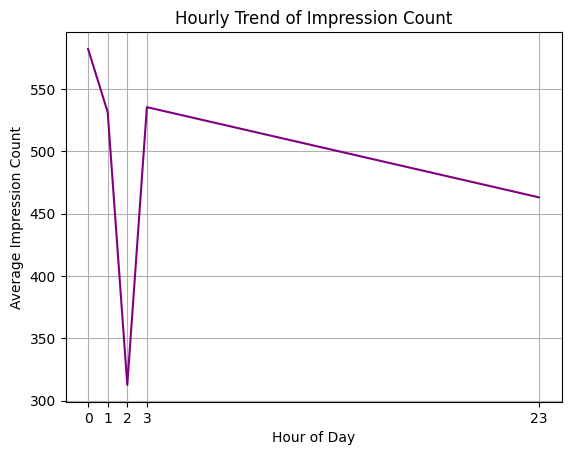

In [13]:
#let's see the engagement based on the impressions per hour
df_clean['created_at'] = pd.to_datetime(df_clean['created_at']) # Ensure 'created_at' is datetime
df_clean['hour'] = df_clean['created_at'].dt.hour
# Aggregate to get hourly impressions
hourly_impressions = df_clean.groupby('hour')['public_metrics.impression_count'].mean().reset_index()

#line chart
plt.plot(hourly_impressions['hour'], hourly_impressions['public_metrics.impression_count'], color ='purple')
plt.xlabel('Hour of Day')
plt.ylabel('Average Impression Count')
plt.title('Hourly Trend of Impression Count')
plt.xticks(hourly_impressions['hour'])
plt.grid(True)
plt.show()

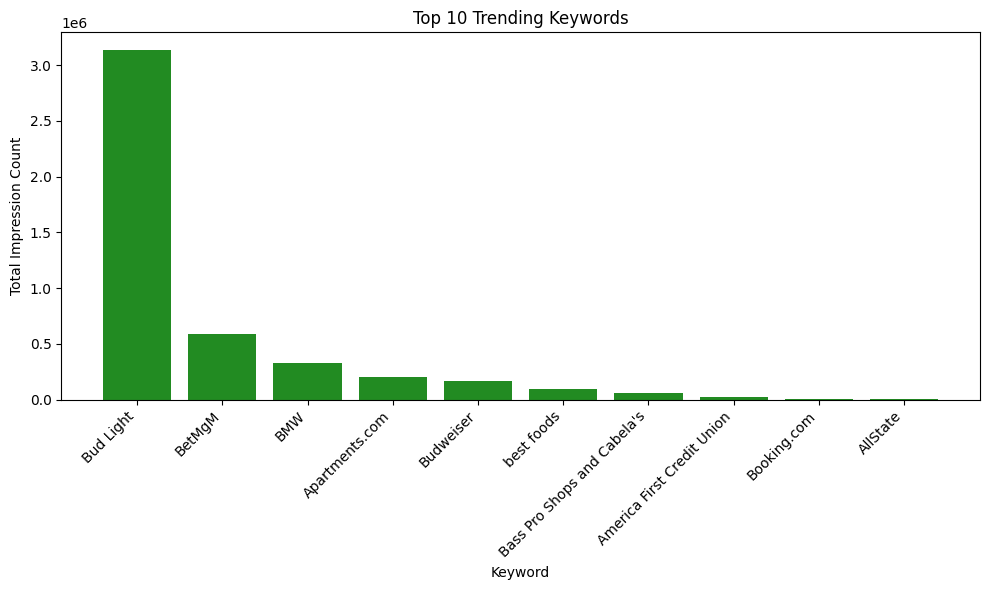

In [14]:
#let's see what keywords were trending
keyword_impressions = df_clean.groupby('keyword')['public_metrics.impression_count'].sum().reset_index()

#sorting by impression count in descending order
keyword_impressions = keyword_impressions.sort_values(by=['public_metrics.impression_count'], ascending=False)

#selecting the top 10 keywords
top_keywords = keyword_impressions.head(10)

#barchart
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.bar(top_keywords['keyword'], top_keywords['public_metrics.impression_count'], color = 'forestgreen')
plt.xlabel('Keyword')
plt.ylabel('Total Impression Count')
plt.title('Top 10 Trending Keywords')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()